# Exploratory data analysis
> How δ13C and MIR spectra differ between batches

Each batch is a set of cassava plants grown under its own conditions and scanned at its own time, on the same spectrometer. This notebook looks at how much of the δ13C variation and of the spectral variation is between batches, because that decides how models should be validated and whether a global model across batches makes sense.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from soilspectfm.all import *
from cassava.data import *

In [ ]:
#| eval: false
d = load_data('../data')
df = pd.DataFrame(dict(c13=d.y, batch=d.batch))

## δ13C by batch

In [ ]:
#| eval: false
df.groupby('batch').c13.describe().round(2)

,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
1456,149.0,-23.85,1.20,-26.50,-24.77,-23.80,-22.99,-21.48
1586,168.0,-28.87,1.00,-30.68,-29.63,-28.94,-28.25,-26.12
1592,244.0,-26.06,0.85,-28.72,-26.59,-26.12,-25.49,-23.69
1597,97.0,-28.11,0.78,-30.39,-28.70,-28.16,-27.64,-25.96
1678,144.0,-25.56,1.62,-28.72,-26.73,-25.95,-24.29,-22.26
1722,177.0,-28.54,1.11,-30.93,-29.32,-28.51,-27.75,-26.05
1723,179.0,-27.36,1.26,-30.74,-28.35,-27.37,-26.35,-23.75


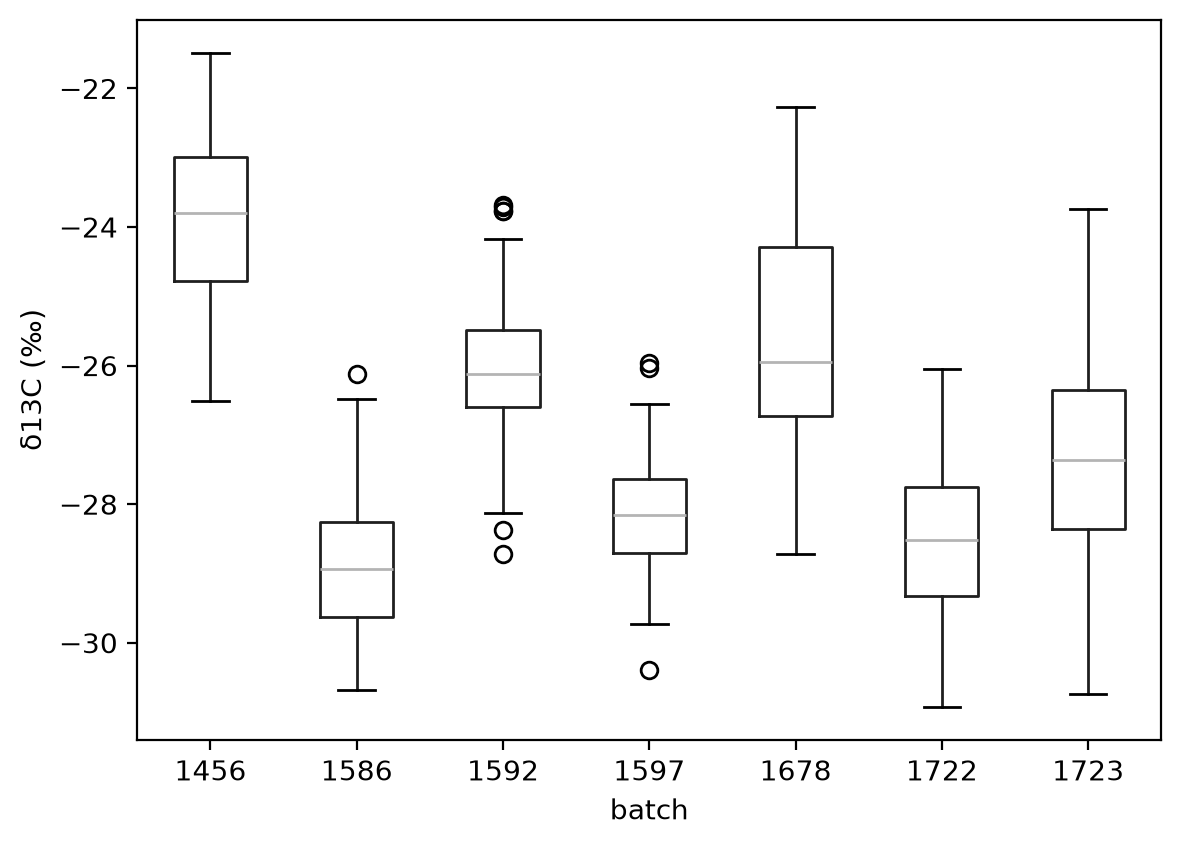

In [ ]:
#| eval: false
ax = df.boxplot(column='c13', by='batch', grid=False)
ax.figure.suptitle('')
ax.set(title='', ylabel='δ13C (‰)');

The share of the δ13C variance that lies between batches is the sum of squares of the batch means around the overall mean, divided by the total sum of squares (η²). A model that only learned which batch a sample came from would reach an R² of about this value on a random split, so it is the baseline to compare random-split scores with.

In [ ]:
def eta2(v, groups):
    "Share of the variance of `v` that lies between `groups`"
    v = pd.Series(v)
    m = v.groupby(np.asarray(groups)).transform('mean')
    return ((m - v.mean())**2).sum() / ((v - v.mean())**2).sum()

In [ ]:
#| eval: false
eta2(d.y, d.batch)

np.float64(0.6766030126145667)

## Spectra by batch

Mean spectrum of each batch:

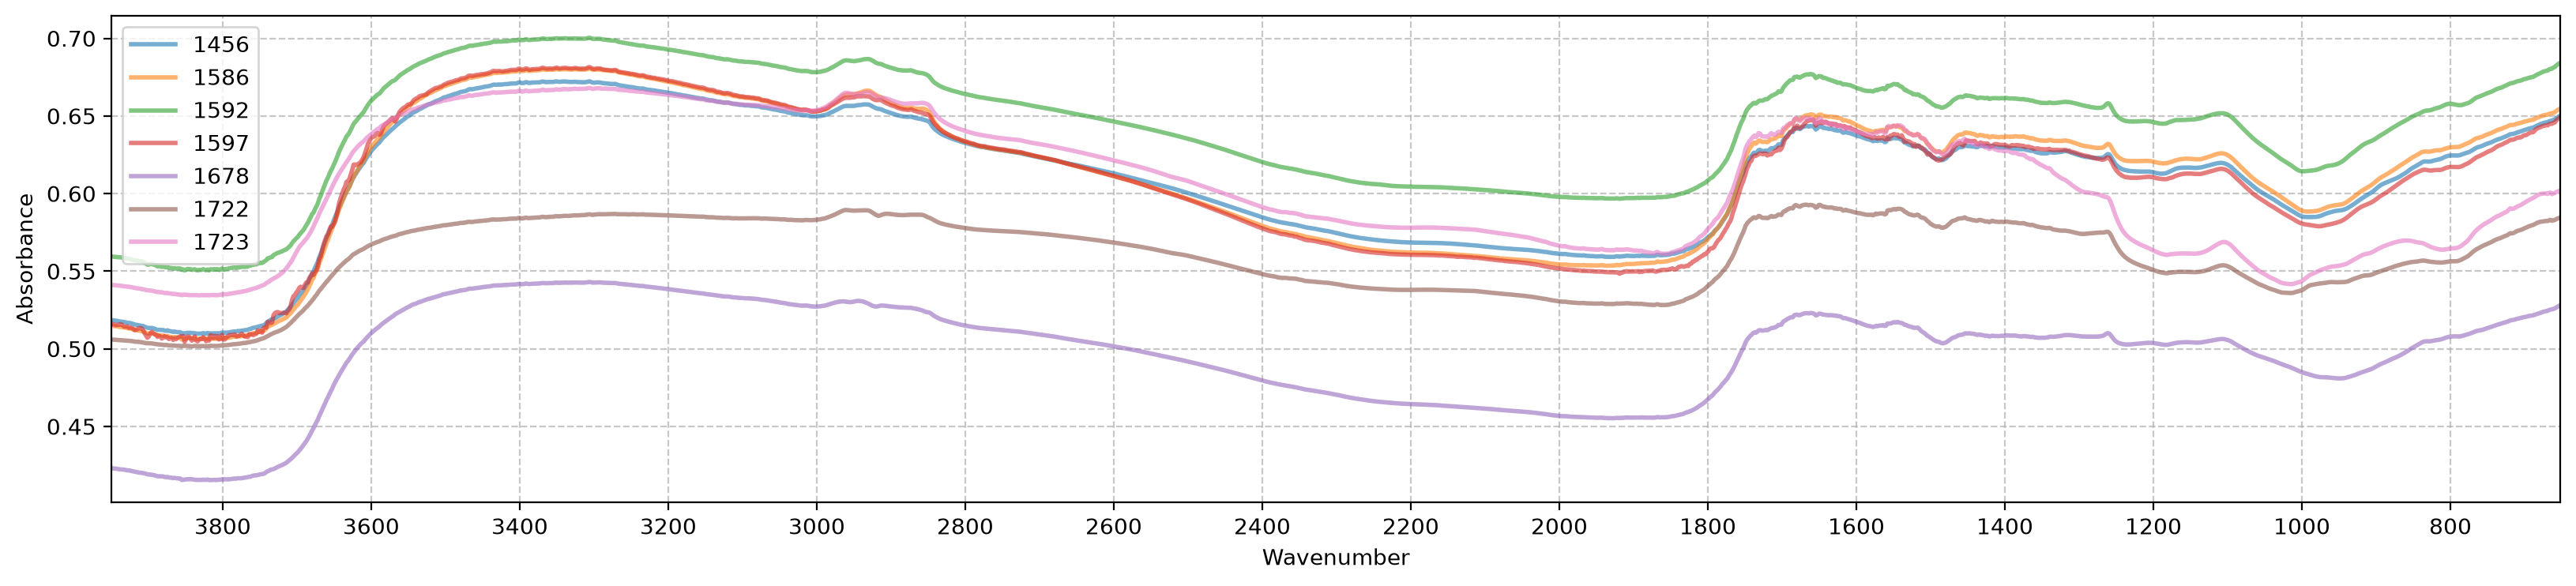

In [ ]:
#| eval: false
fig, ax = plt.subplots(figsize=(20, 4))
for b in np.unique(d.batch): plot_spectra(d.X[d.batch == b].mean(0), d.ws, ascending=False, ax=ax, color=None, label=b, lw=2)
ax.legend();

## PCA scores by batch

PCA on the raw spectra, on SNV-corrected spectra, and on the Savitzky-Golay first derivative of the SNV-corrected spectra. SNV centres and scales each spectrum on its own, which removes differences in baseline offset and overall intensity between samples. If the batches differ mainly in those, they separate less after SNV. The first derivative also removes any remaining baseline curvature and sharpens overlapping bands, so what is left is differences in band shape and position.

In [ ]:
#| eval: false
snv_sg1 = make_pipeline(SNV(), SavitzkyGolay(deriv=1))
Xs = dict(raw=d.X, snv=SNV().fit_transform(d.X), snv_sg1=snv_sg1.fit_transform(d.X))
pcas = {k: PCA(n_components=2).fit(X) for k, X in Xs.items()}
scores = {k: pcas[k].transform(X) for k, X in Xs.items()}

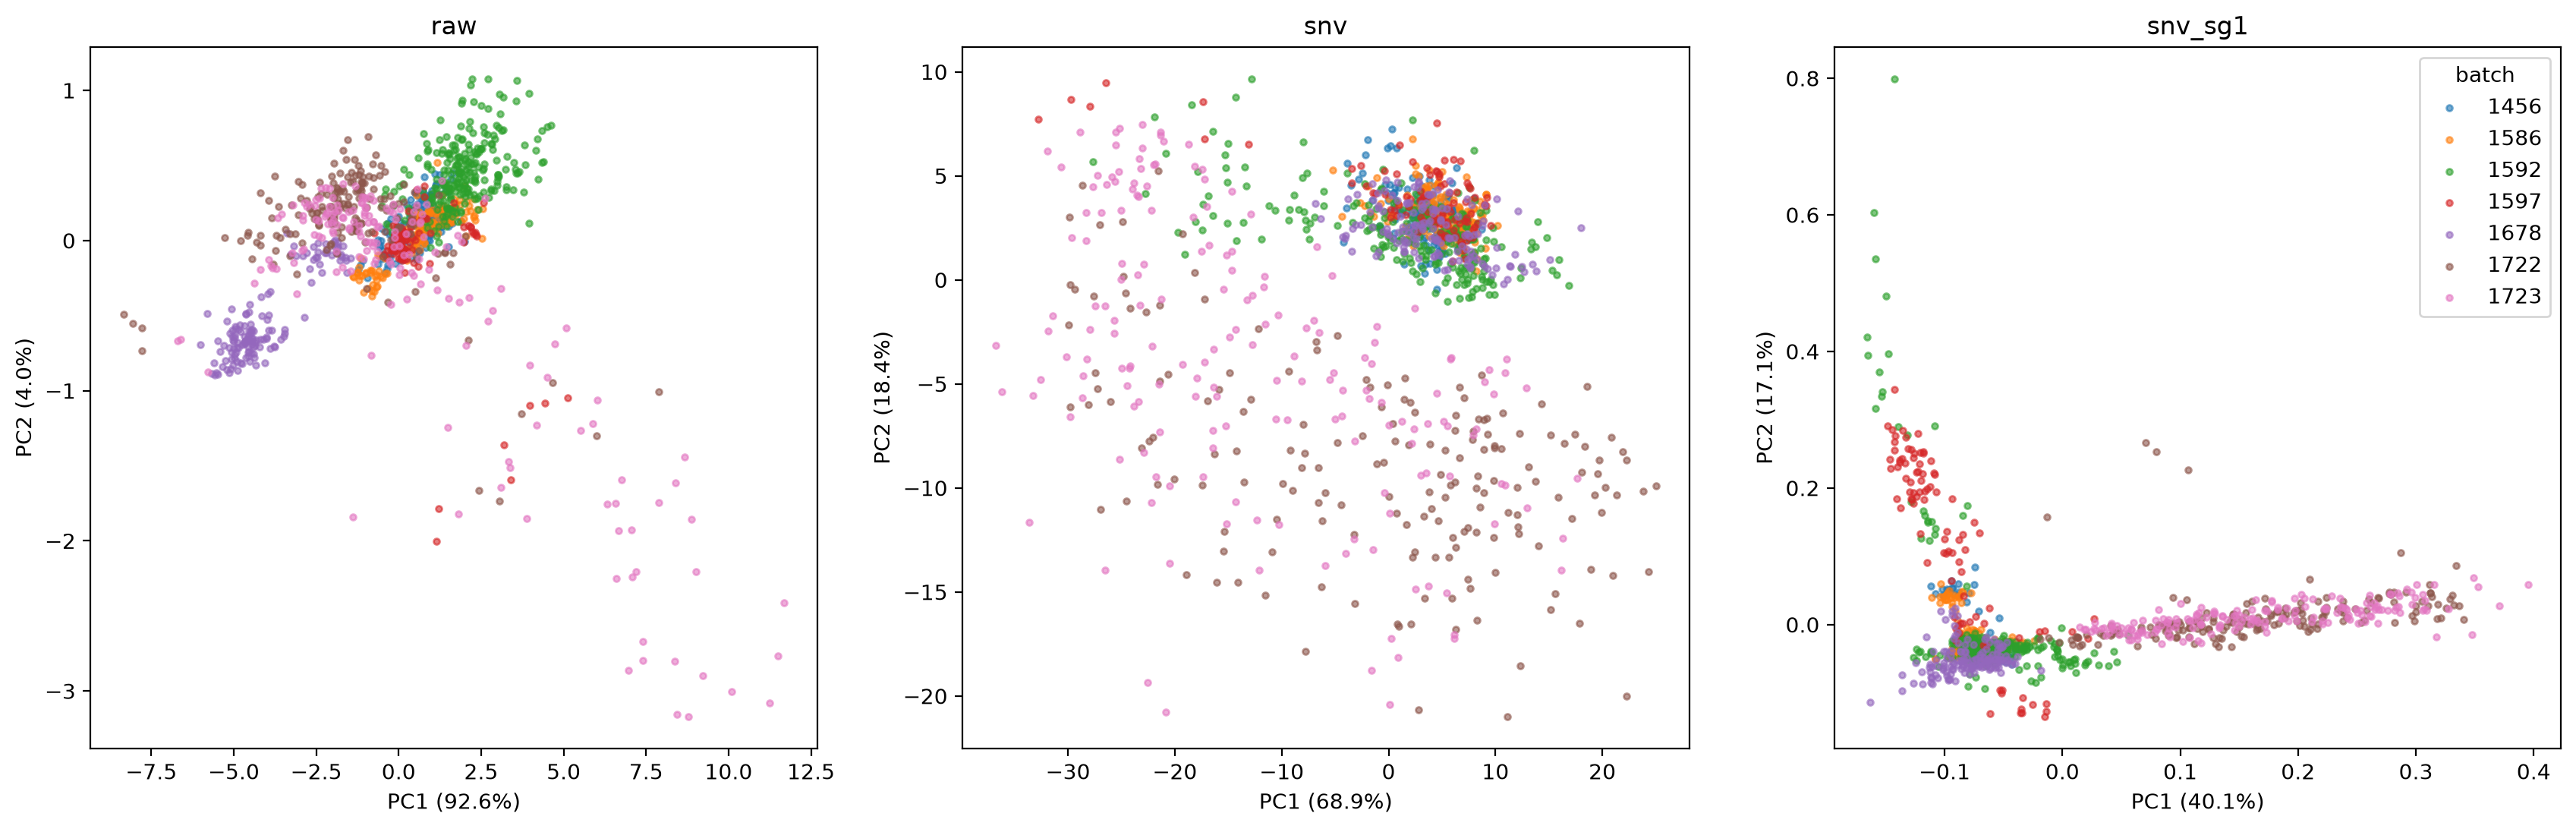

In [ ]:
#| eval: false
fig, axs = plt.subplots(1, len(scores), figsize=(7*len(scores), 6))
for ax, (k, s) in zip(axs, scores.items()):
    for b in np.unique(d.batch): ax.scatter(*s[d.batch == b].T, s=8, alpha=0.6, label=b)
    r = pcas[k].explained_variance_ratio_
    ax.set(title=k, xlabel=f'PC1 ({r[0]:.1%})', ylabel=f'PC2 ({r[1]:.1%})')
axs[-1].legend(title='batch');

The between-batch share (η²) of each score measures how strongly the batches separate along that component:

In [ ]:
#| eval: false
pd.DataFrame({k: [eta2(s[:, i], d.batch) for i in (0, 1)] for k, s in scores.items()}, index=['PC1', 'PC2']).round(2)

,raw,snv,snv_sg1
PC1,0.49,0.29,0.80
PC2,0.37,0.63,0.25


The loadings of the SNV PCA show which wavenumbers drive each component:

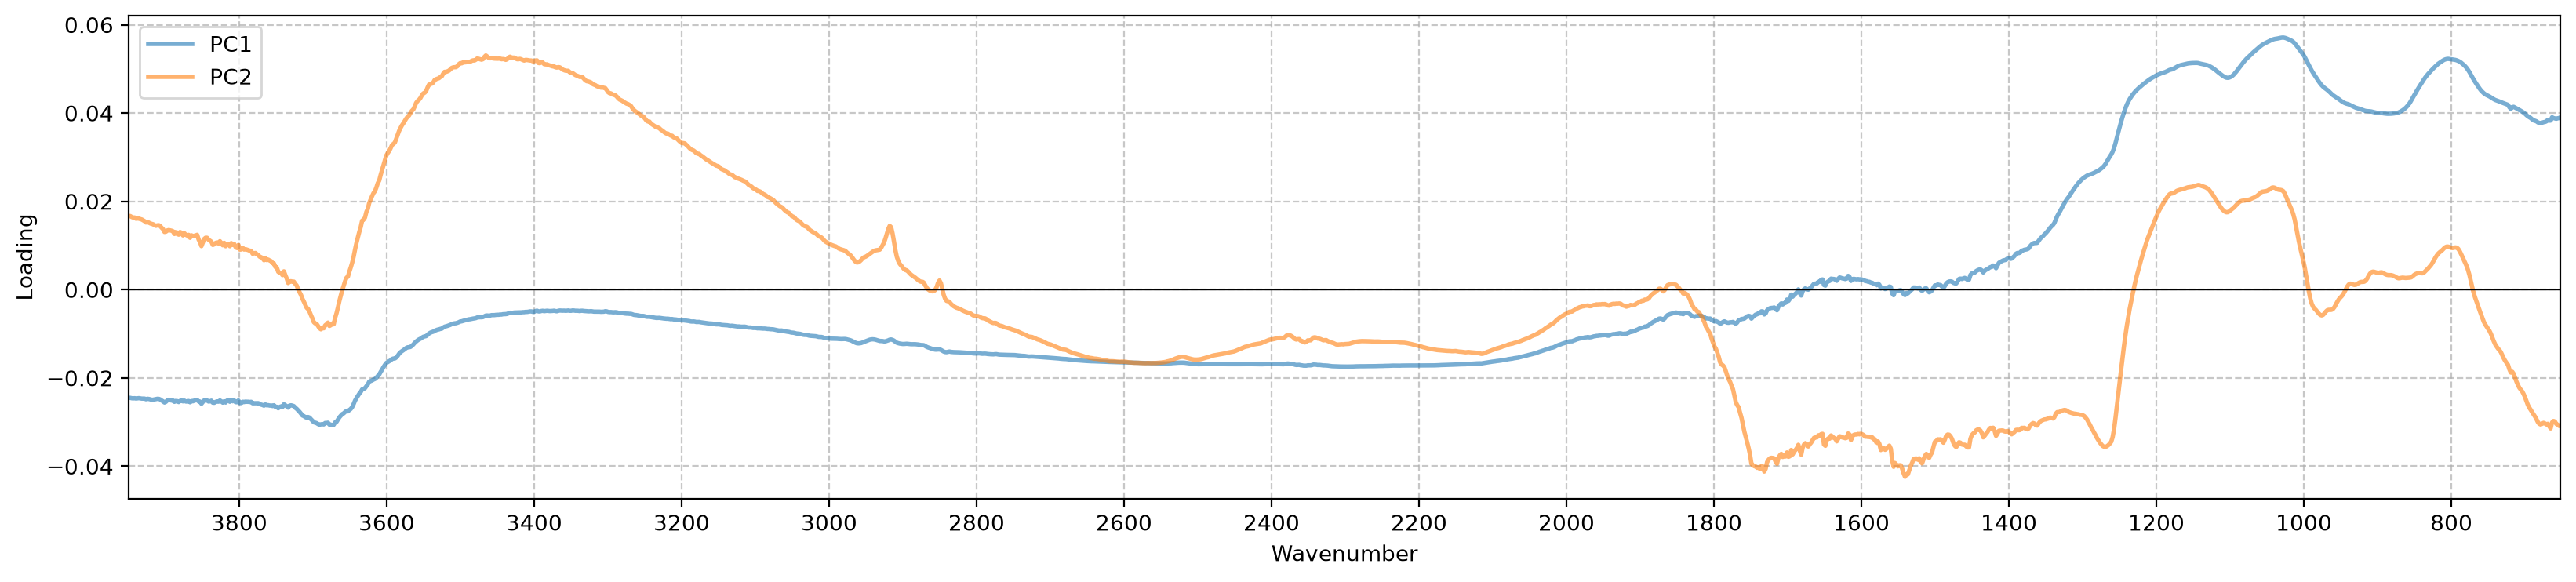

In [ ]:
#| eval: false
fig, ax = plt.subplots(figsize=(20, 4))
for i, l in enumerate(pcas['snv'].components_): plot_spectra(l, d.ws, ascending=False, ax=ax, ylabel='Loading', color=None, label=f'PC{i+1}', lw=2)
ax.axhline(0, color='k', lw=0.5)
ax.legend();

The `snv_sg1` scores coloured by δ13C show whether the two arms follow δ13C:

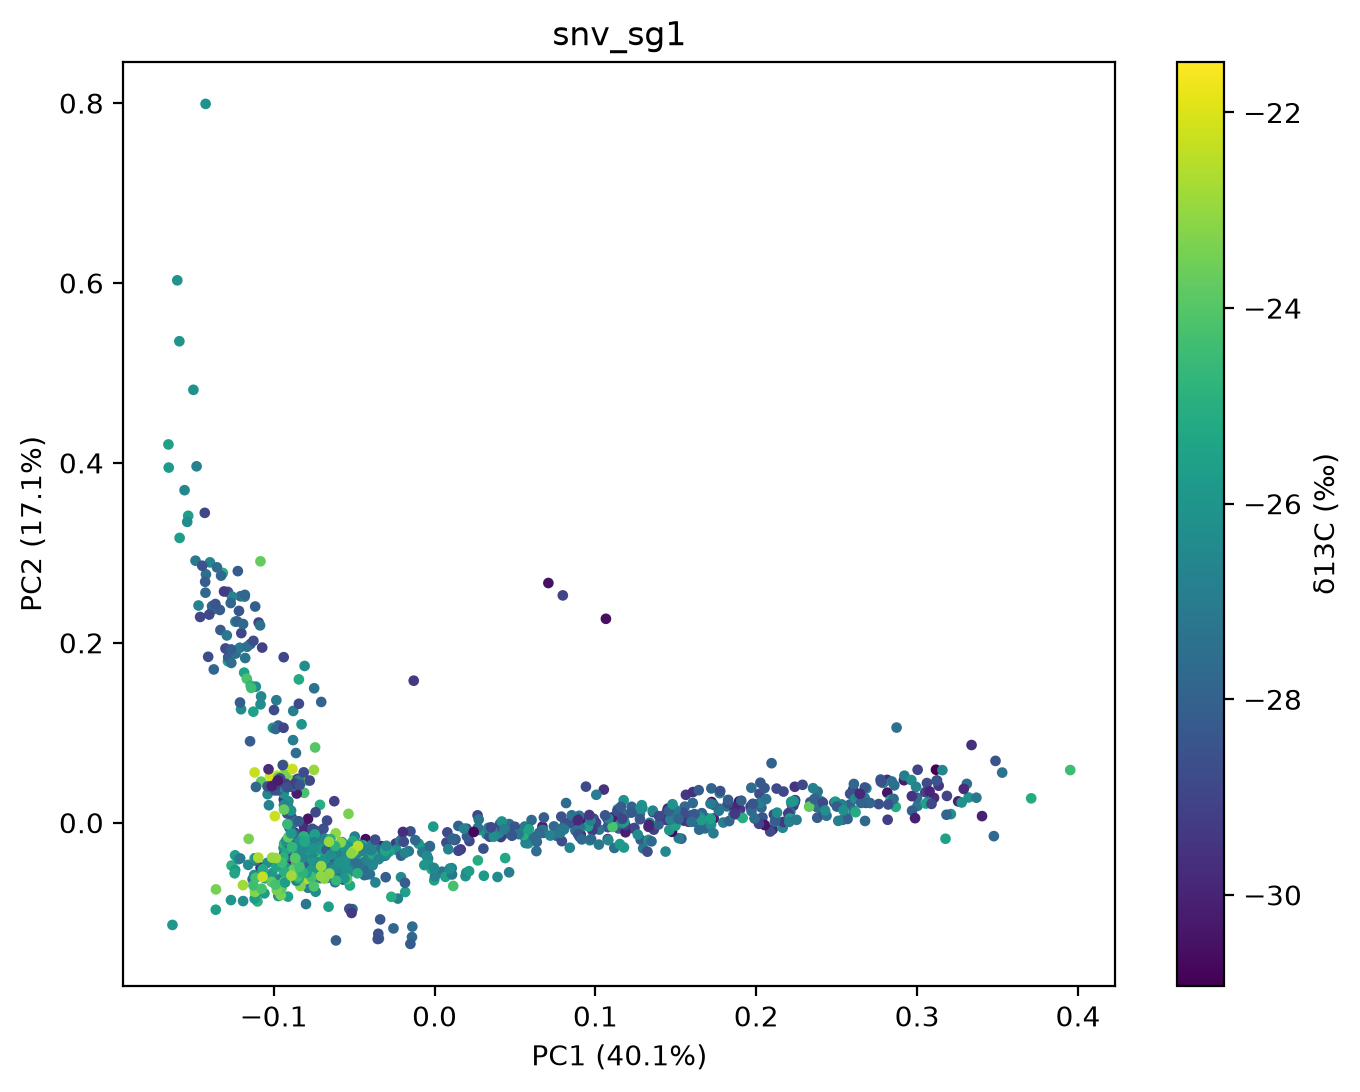

In [ ]:
#| eval: false
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(*scores['snv_sg1'].T, c=d.y, s=8, cmap='viridis')
r = pcas['snv_sg1'].explained_variance_ratio_
ax.set(title='snv_sg1', xlabel=f'PC1 ({r[0]:.1%})', ylabel=f'PC2 ({r[1]:.1%})')
fig.colorbar(sc, label='δ13C (‰)');

## Isolated samples

Four samples sit apart from both arms and the core of the `snv_sg1` scores, at PC1 > -0.05 and PC2 > 0.12:

In [ ]:
#| eval: false
s = scores['snv_sg1']
odd = (s[:, 0] > -0.05) & (s[:, 1] > 0.12)
pd.DataFrame(dict(id=d.ids[odd], batch=d.batch[odd], c13=d.y[odd], pc1=s[odd, 0], pc2=s[odd, 1])).round(3)

,id,batch,c13,pc1,pc2
0,1722_092,1722,-29.017,0.080,0.253
1,1722_120,1722,-30.594,0.107,0.227
2,1722_138,1722,-29.358,-0.013,0.158
3,1722_147,1722,-30.548,0.071,0.266


All four come from batch 1722. Their spectra, against the mean spectrum of the rest of batch 1722:

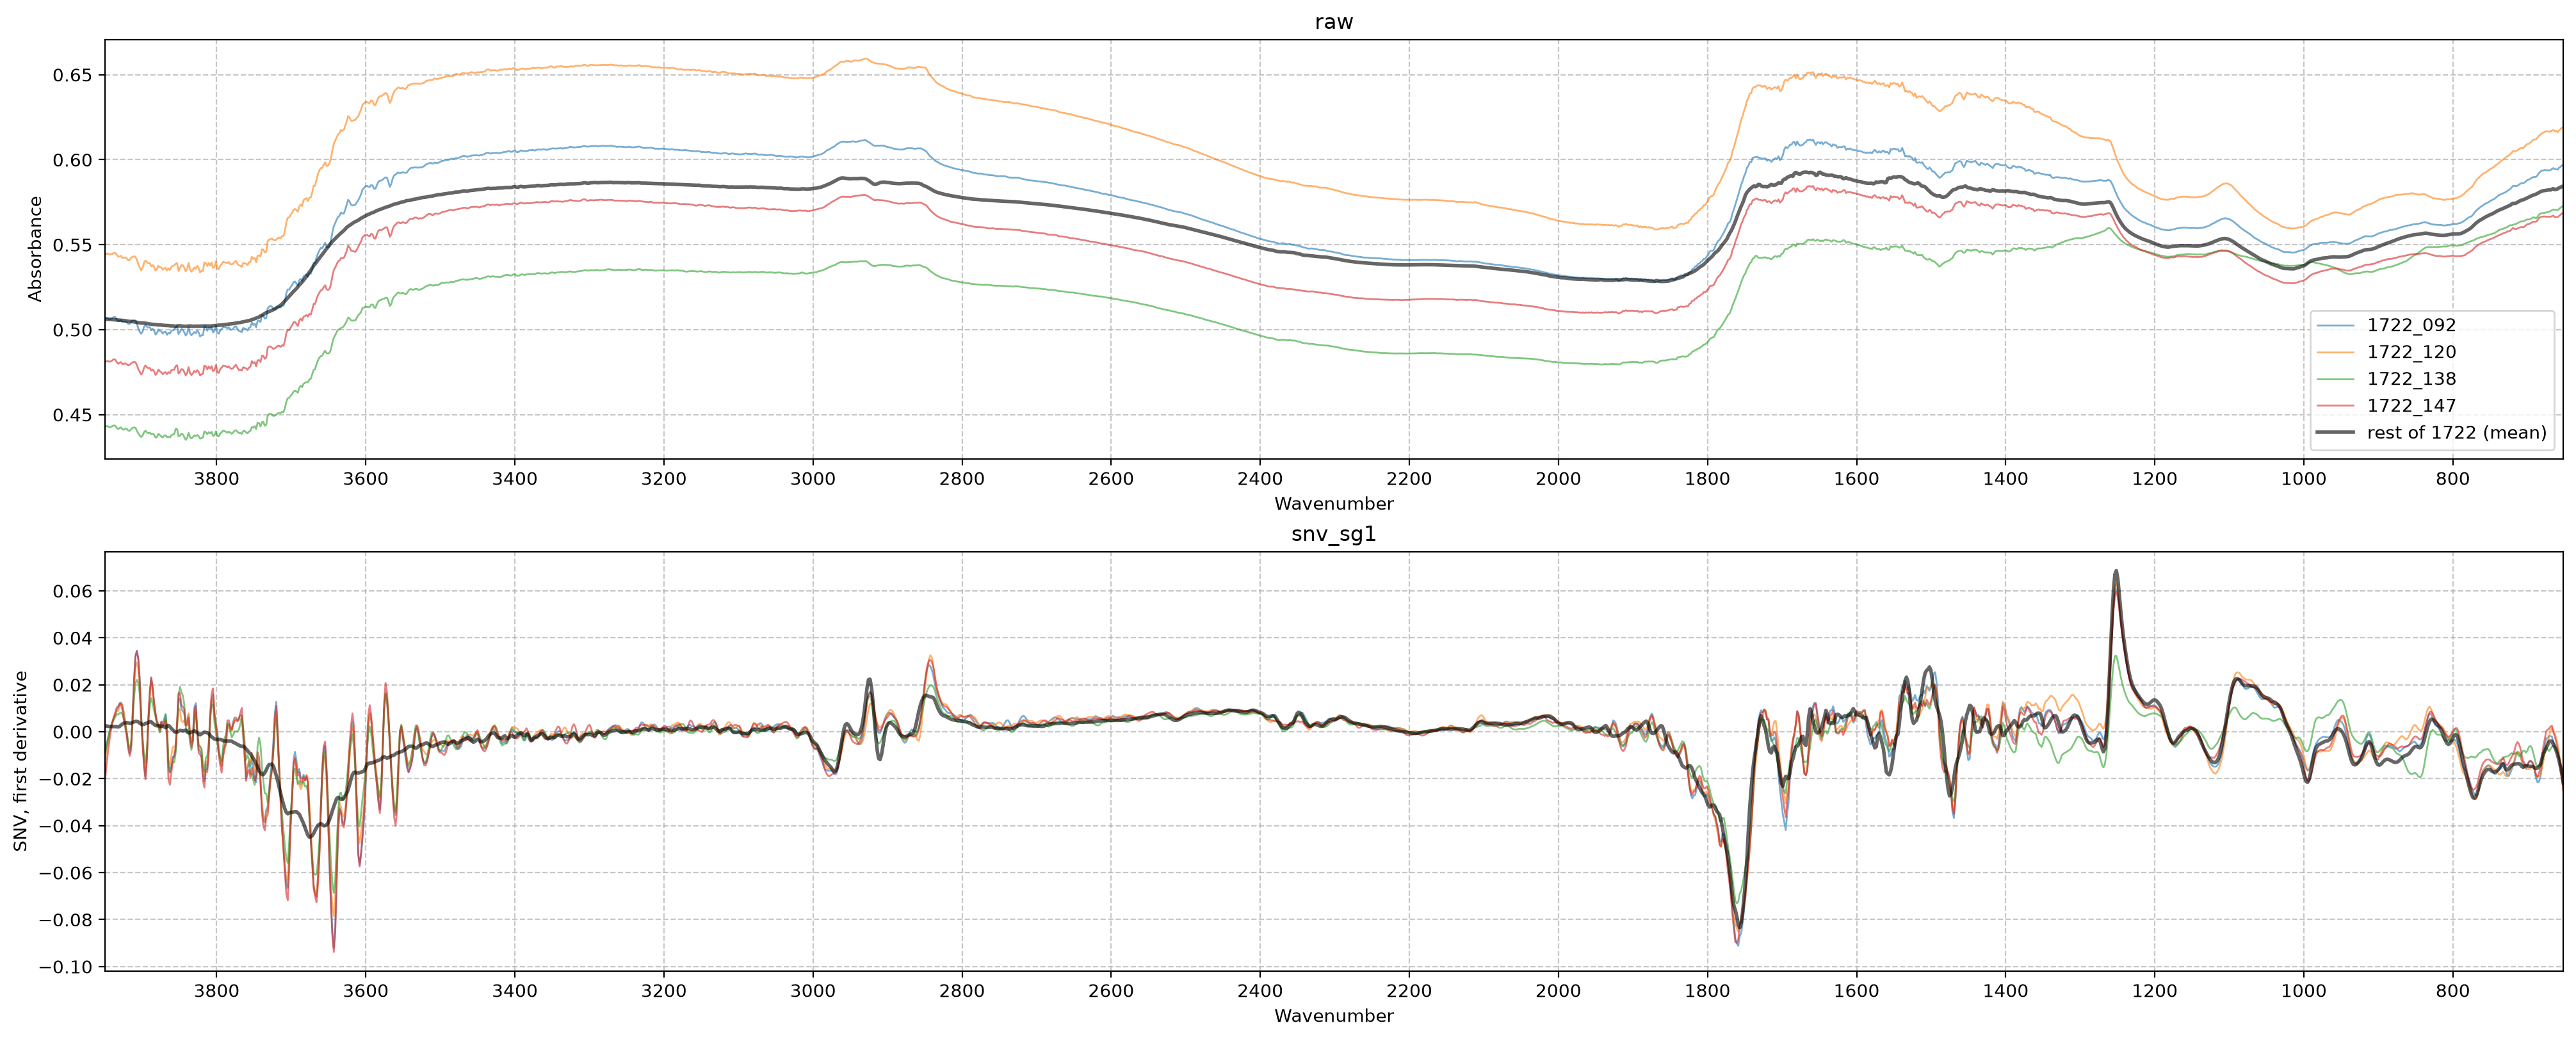

In [ ]:
#| eval: false
rest = (d.batch == '1722') & ~odd
fig, axs = plt.subplots(2, 1, figsize=(20, 8), layout='constrained')
for ax, k, yl in zip(axs, ('raw', 'snv_sg1'), ('Absorbance', 'SNV, first derivative')):
    for i in np.flatnonzero(odd): plot_spectra(Xs[k][i], d.ws, ascending=False, ax=ax, title=k, ylabel=yl, color=None, label=d.ids[i])
    plot_spectra(Xs[k][rest].mean(0), d.ws, ascending=False, ax=ax, title=k, ylabel=yl, color='k', lw=2, label='rest of 1722 (mean)')
axs[0].legend();

## Water vapour

Water vapour in the beam adds sharp, regular lines to a spectrum, strongest between about 3900 and 3550 cm⁻¹. `vapour_index` measures them as the spread of the narrow features in that window: the residual of each SNV spectrum after Savitzky-Golay smoothing, which keeps the narrow vapour lines and removes the broad edge of the leaf O-H band. Random noise also raises the index, so it flags candidates rather than proving vapour.

In [ ]:
def vapour_index(
    X, # SNV-corrected spectra, one per row
    ws, # Wavenumbers (cm⁻¹)
    lo=3550, # Lower edge of the window (cm⁻¹)
    hi=3900, # Upper edge of the window (cm⁻¹)
    window_length=11, # Savitzky-Golay smoothing window, in points
):
    "Spread of the narrow features of each spectrum between `lo` and `hi`"
    hp = X - SavitzkyGolay(window_length=window_length).fit_transform(X)
    return hp[:, (ws >= lo) & (ws <= hi)].std(1)

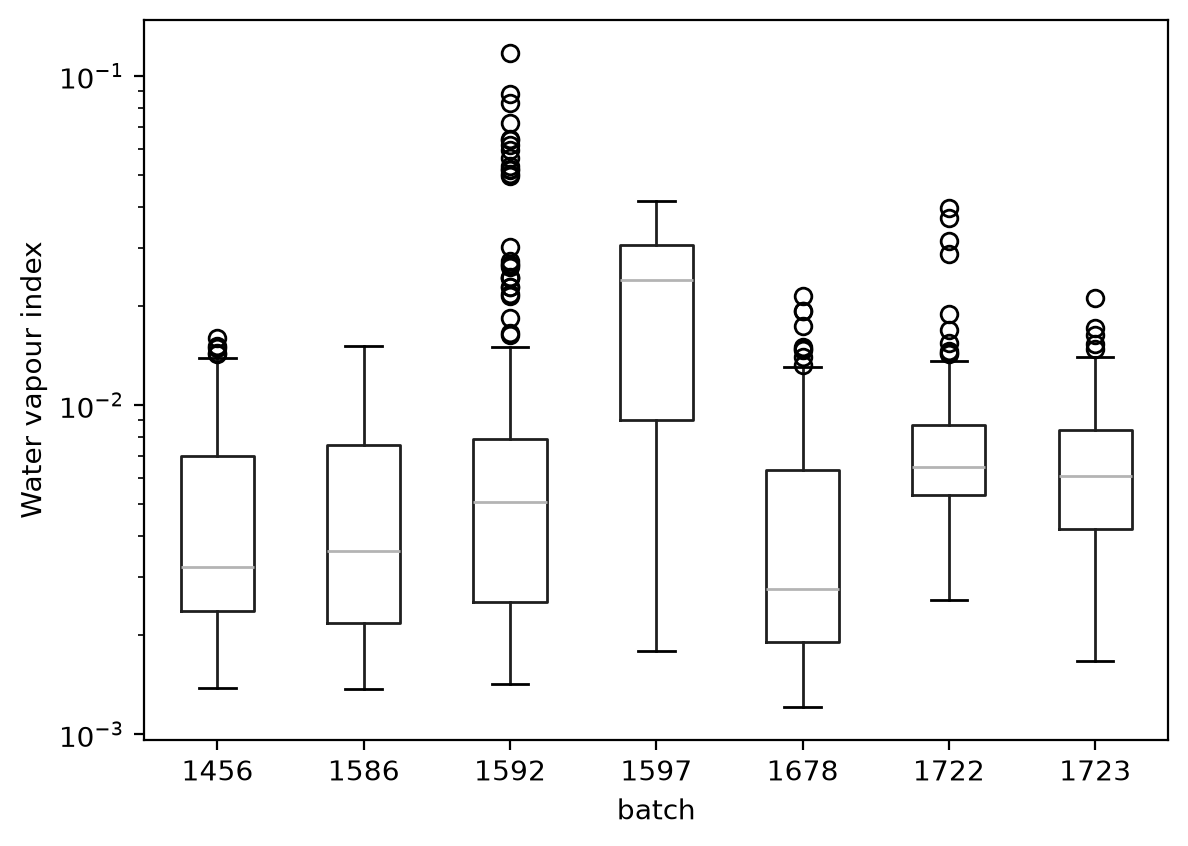

In [ ]:
#| eval: false
vi = vapour_index(Xs['snv'], d.ws)
ax = pd.DataFrame(dict(vi=vi, batch=d.batch)).boxplot(column='vi', by='batch', grid=False)
ax.figure.suptitle('')
ax.set(title='', ylabel='Water vapour index', yscale='log');

The index follows PC2 of the `snv_sg1` scores closely, so the vertical arm in the PCA plot is water vapour:

In [ ]:
#| eval: false
np.corrcoef(vi, scores['snv_sg1'][:, 1])[0, 1]

np.float64(0.9158113813137179)

Samples per batch with an index above three times the overall median, an arbitrary threshold to show the extent:

In [ ]:
#| eval: false
pd.Series(vi > 3*np.median(vi)).groupby(d.batch).agg(['sum', 'mean']).round(2)

,sum,mean
1456,0,0.00
1586,0,0.00
1592,27,0.11
1597,57,0.59
1678,4,0.03
1722,6,0.03
1723,2,0.01
